# Reporting Analysis — Gaming Compliance & Risk Intelligence Platform

Connects to the platform's Snowflake **reporting layer** and charts the results of the
executed build (validated 2026-07-02: 18/18 setup + 21/21 reconciliation/DQ). This notebook
is the *visual analysis* companion to the SQL platform — it queries the `REPORTING.VW_*`
views (and the detection query over `CORE`/`STAGING`) and renders the story with charts.

**Synthetic data only. No credentials appear in this file.**

### How to run
1. Build the platform in Snowflake (see [`../docs/deployment_guide.md`](../docs/deployment_guide.md)).
2. `pip install -r ../requirements.txt`.
3. Provide your connection via **environment variables** (no secrets in the repo):
   `SNOWFLAKE_ACCOUNT`, `SNOWFLAKE_USER`, and either `SNOWFLAKE_PASSWORD` **or** leave it unset
   to use browser/SSO auth. (Or a `connections.toml` entry named `gaming_compliance`.)
4. **Run all cells, then commit the notebook with its outputs** so the charts render on GitHub.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import snowflake.connector

# No credentials in this file. Prefer a connections.toml entry; else build from SNOWFLAKE_* env vars.
try:
    conn = snowflake.connector.connect(connection_name=os.environ.get("SNOWFLAKE_CONNECTION", "gaming_compliance"))
except Exception:
    kwargs = dict(
        account=os.environ["SNOWFLAKE_ACCOUNT"],
        user=os.environ["SNOWFLAKE_USER"],
        role=os.environ.get("SNOWFLAKE_ROLE", "DATA_ENGINEER"),
        warehouse=os.environ.get("SNOWFLAKE_WAREHOUSE", "WH_REPORTING"),
        database="GAMING_COMPLIANCE_DB",
    )
    if os.environ.get("SNOWFLAKE_PASSWORD"):
        kwargs["password"] = os.environ["SNOWFLAKE_PASSWORD"]        # from env, never committed
    else:
        kwargs["authenticator"] = os.environ.get("SNOWFLAKE_AUTHENTICATOR", "externalbrowser")
    conn = snowflake.connector.connect(**kwargs)

# DATA_ENGINEER can read every layer (REPORTING views + CORE/STAGING for the detection query).
for stmt in ("USE ROLE DATA_ENGINEER", "USE WAREHOUSE WH_REPORTING", "USE DATABASE GAMING_COMPLIANCE_DB"):
    conn.cursor().execute(stmt)

def q(sql):
    cur = conn.cursor()
    try:
        cur.execute(sql)
        return cur.fetch_pandas_all()
    finally:
        cur.close()

q("SELECT CURRENT_ROLE() AS ROLE, CURRENT_WAREHOUSE() AS WH, CURRENT_DATABASE() AS DB")

/Users/user/Documents/Portfolio/gaming-compliance-risk-platform-snowflake/.venv/lib/python3.9/site-packages/snowflake/connector/vendored/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/user/Documents/Portfolio/gaming-compliance-risk-platform-snowflake/.venv/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,ROLE,WH,DB
0,DATA_ENGINEER,WH_REPORTING,GAMING_COMPLIANCE_DB


## 1. Executive KPI snapshot
One-row view, transposed to a legible metric → value list.

In [2]:
kpi = q("SELECT * FROM REPORTING.VW_EXECUTIVE_OVERVIEW").T
kpi.columns = ["value"]
kpi

,value
TOTAL_TRANSACTIONS,5310
TOTAL_TRANSACTION_VALUE,32157132.0
TOTAL_WAGERS,20910000000.00
TOTAL_GGR,1630980000.00
HOLD_PCT,7.80
LATEST_ACTIVE_ACCOUNTS,1025000
GGR_PER_ACTIVE,1591.20
AML_ALERTS,5749
ESCALATED_ALERTS,5117
AVG_RISK_SCORE,77.0


## 2. AML alerts by typology
All 11 rule typologies and how many alerts each raised.

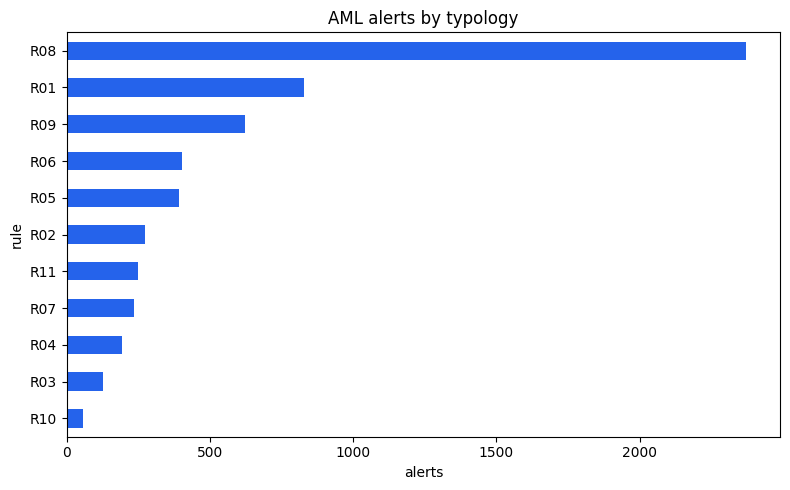

,RULE_CODE,RULE_NAME,ALERTS,ESCALATED
0,R10,Counterparty Concentration,57,17
1,R03,Rapid Movement of Funds,127,127
2,R04,High Transaction Velocity,192,192
3,R07,Unusual Activity Spike,236,232
4,R11,Sanctions / Watchlist Match,250,250
5,R02,Structuring,273,273
6,R05,Repeated Sub-Threshold,392,392
7,R06,High-Risk Payment Method,401,54
8,R09,High-Risk Player / Account,623,382
9,R01,Large Transaction,827,827


In [3]:
typ = q("SELECT RULE_CODE, RULE_NAME, ALERTS, ESCALATED FROM REPORTING.VW_ALERT_TYPOLOGY_BREAKDOWN ORDER BY ALERTS")
ax = typ.plot.barh(x="RULE_CODE", y="ALERTS", legend=False, figsize=(8,5), color="#2563eb")
ax.set_title("AML alerts by typology"); ax.set_xlabel("alerts"); ax.set_ylabel("rule")
plt.tight_layout(); plt.show()
typ

## 3. Monthly compliance trends
Alerts, escalations, and STR cases over the synthetic time window.

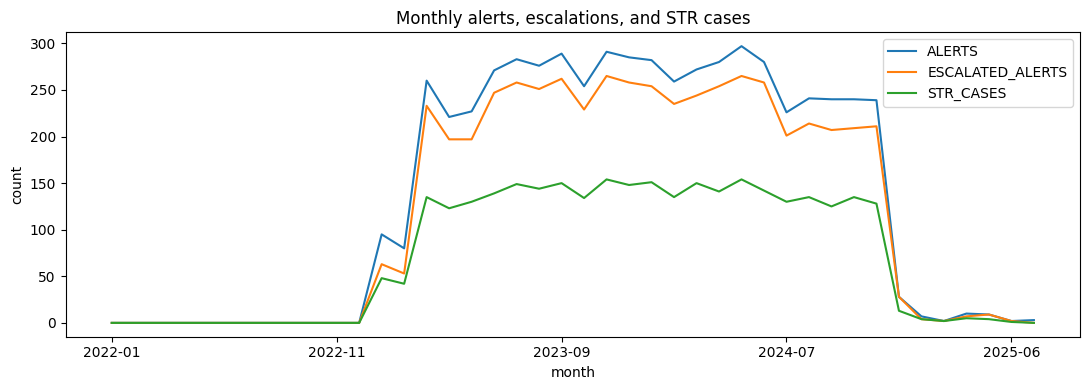

In [4]:
tr = q("SELECT YEAR_MONTH, ALERTS, ESCALATED_ALERTS, STR_CASES FROM REPORTING.VW_MONTHLY_COMPLIANCE_TRENDS ORDER BY YEAR_MONTH")
ax = tr.plot(x="YEAR_MONTH", y=["ALERTS","ESCALATED_ALERTS","STR_CASES"], figsize=(11,4))
ax.set_title("Monthly alerts, escalations, and STR cases"); ax.set_xlabel("month"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

## 4. Market / GGR performance
Monthly wagers and gross gaming revenue (synthetic, illustrative).

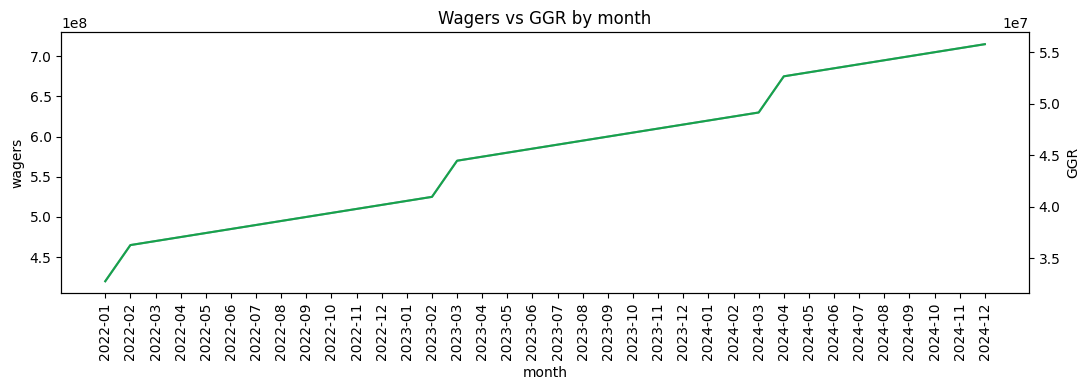

In [5]:
mkt = q("SELECT YEAR_MONTH, TOTAL_WAGERS, TOTAL_GGR FROM REPORTING.VW_MARKET_PERFORMANCE ORDER BY YEAR_MONTH")
fig, ax1 = plt.subplots(figsize=(11,4))
ax1.plot(mkt["YEAR_MONTH"], mkt["TOTAL_WAGERS"], color="#94a3b8", label="wagers")
ax2 = ax1.twinx(); ax2.plot(mkt["YEAR_MONTH"], mkt["TOTAL_GGR"], color="#16a34a", label="GGR")
ax1.set_title("Wagers vs GGR by month"); ax1.set_xlabel("month"); ax1.set_ylabel("wagers"); ax2.set_ylabel("GGR")
ax1.tick_params(axis='x', labelrotation=90)
plt.tight_layout(); plt.show()

## 5. STR SLA performance by priority
Case volume and SLA breaches per priority tier.

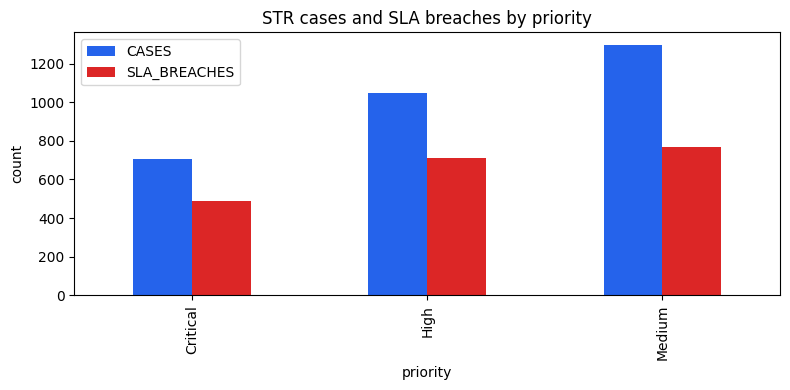

,CASE_PRIORITY,CASES,SLA_BREACHES,SLA_COMPLIANCE_PCT
0,Critical,705,491,55.9
1,High,1048,709,60.1
2,Medium,1298,768,70.5


In [6]:
sla = q("SELECT CASE_PRIORITY, CASES, SLA_BREACHES, SLA_COMPLIANCE_PCT FROM REPORTING.VW_SLA_PERFORMANCE ORDER BY SLA_TARGET_DAYS")
ax = sla.plot.bar(x="CASE_PRIORITY", y=["CASES","SLA_BREACHES"], figsize=(8,4), color=["#2563eb","#dc2626"])
ax.set_title("STR cases and SLA breaches by priority"); ax.set_xlabel("priority"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()
sla

## 6. Detection performance vs. synthetic ground truth
Scores the rule engine against the injected `IS_LAUNDERING` label (recall / precision / F1).

> **Optimistic by construction:** the synthetic laundering patterns are the ones the rules
> target, so this shows the rules catch their intended typologies — not production performance.

In [7]:
perf = q('''
WITH labelled AS (
    SELECT t.TRANSACTION_KEY, s.IS_LAUNDERING,
           IFF(a.TRANSACTION_KEY IS NOT NULL, TRUE, FALSE) AS FLAGGED
    FROM CORE.FACT_TRANSACTIONS t
    JOIN STAGING.STG_TRANSACTIONS s ON s.TRANSACTION_ID = t.TRANSACTION_ID AND s.IS_VALID
    LEFT JOIN (SELECT DISTINCT TRANSACTION_KEY FROM CORE.FACT_AML_ALERTS) a
      ON a.TRANSACTION_KEY = t.TRANSACTION_KEY
), cm AS (
    SELECT SUM(IFF(IS_LAUNDERING AND FLAGGED,1,0)) TP,
           SUM(IFF(NOT IS_LAUNDERING AND FLAGGED,1,0)) FP,
           SUM(IFF(IS_LAUNDERING AND NOT FLAGGED,1,0)) FN,
           SUM(IFF(NOT IS_LAUNDERING AND NOT FLAGGED,1,0)) TN FROM labelled
)
SELECT TP, FP, FN, TN,
       ROUND(100.0*TP/NULLIF(TP+FN,0),1) AS RECALL_PCT,
       ROUND(100.0*TP/NULLIF(TP+FP,0),1) AS PRECISION_PCT,
       ROUND(2.0*TP/NULLIF(2*TP+FP+FN,0),3) AS F1 FROM cm''')
perf

,TP,FP,FN,TN,RECALL_PCT,PRECISION_PCT,F1
0,563,2687,1,2059,99.8,17.3,0.295


## Findings

_(Fill in after running — which typologies dominate, escalation rate, STR conversion, GGR
trend, and the detection recall/precision/F1 above. Mirrors the analyst version's Key
Findings, produced directly from the Snowflake reporting layer.)_